In [ ]:
# %run evaluate_experiments.py --dataset politifact --shot 4

===== 최종 모델 성능 평가 및 실험 분석 보고서 =====

📊 분석 보고서: PolitiFact Dataset (Baseline)
Accuracy (정확도):   48.28%
Precision (정밀도):  0.4667
Recall (재현율):     0.5000
F1-Score:            0.4828


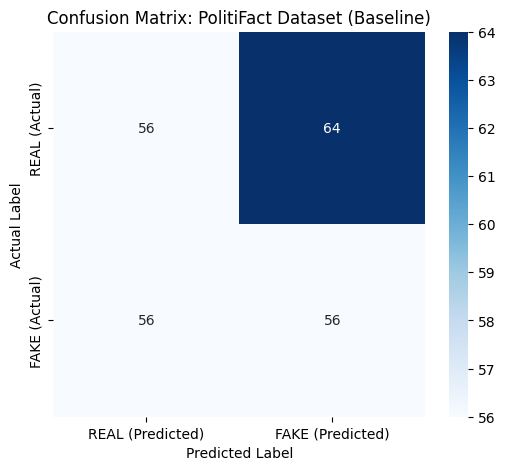


📊 분석 보고서: GossipCop Dataset (240 Sample)
Accuracy (정확도):   46.12%
Precision (정밀도):  0.4567
Recall (재현율):     0.5088
F1-Score:            0.4813


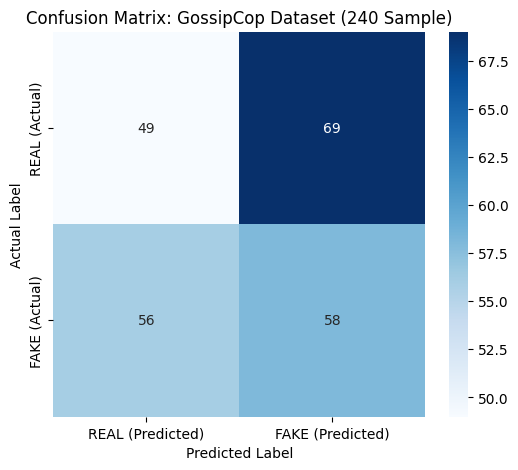


📊 분석 보고서: 실험 1: PolitiFact with Class Weighting
Accuracy (정확도):   48.71%
Precision (정밀도):  0.4653
Recall (재현율):     0.4196
F1-Score:            0.4413


/Users/hyunakim/miniforge3/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/hyunakim/miniforge3/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


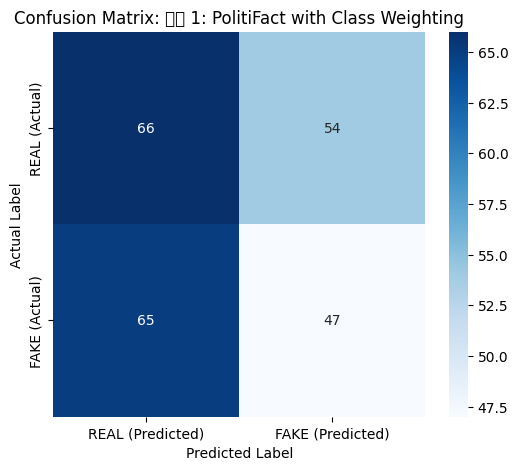


📊 분석 보고서: 실험 2: PolitiFact With Emotion (Baseline)
Accuracy (정확도):   55.17%
Precision (정밀도):  0.5392
Recall (재현율):     0.4911
F1-Score:            0.5140


/Users/hyunakim/miniforge3/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/hyunakim/miniforge3/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


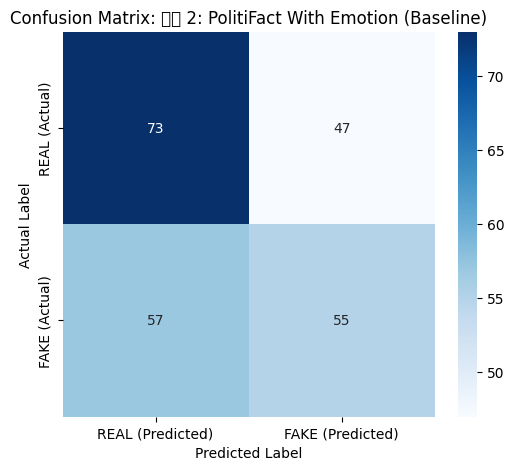


📊 분석 보고서: 실험 2: PolitiFact Without Emotion (Ablation)
Accuracy (정확도):   52.16%
Precision (정밀도):  0.5054
Recall (재현율):     0.4196
F1-Score:            0.4585


/Users/hyunakim/miniforge3/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/hyunakim/miniforge3/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


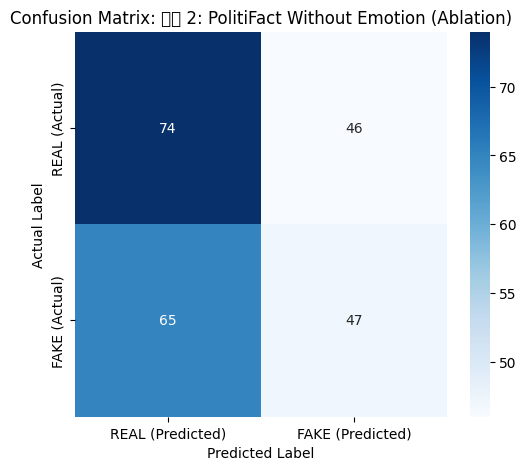


📊 분석 보고서: 실험 3: PolitiFact Without Beta Weighting (Ablation)
Accuracy (정확도):   50.86%
Precision (정밀도):  0.4902
Recall (재현율):     0.4464
F1-Score:            0.4673


/Users/hyunakim/miniforge3/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/hyunakim/miniforge3/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


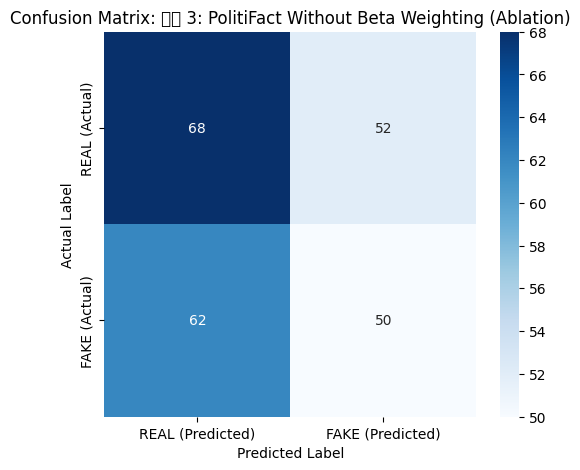


===== 모든 분석 완료 =====


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def analyze_and_visualize_results(df: pd.DataFrame, report_title: str):

    y_true = df['label']
    y_pred = df['predict']

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n{'='*25}\n📊 분석 보고서: {report_title}\n{'='*25}")
    print(f"Accuracy (정확도):   {accuracy:.2%}")
    print(f"Precision (정밀도):  {precision:.4f}")
    print(f"Recall (재현율):     {recall:.4f}")
    print(f"F1-Score:            {f1:.4f}")
    
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['REAL (Predicted)', 'FAKE (Predicted)'], 
                yticklabels=['REAL (Actual)', 'FAKE (Actual)'])
    plt.title(f'Confusion Matrix: {report_title}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()


BASE_DIR = os.getcwd()

# 1. evaluate_on_datasets의 결과 (프로젝트 루트에 위치)
baseline_reports = [
    {"title": "PolitiFact Dataset (Baseline)", "filepath": os.path.join(BASE_DIR, "politifact_evaluation_results.csv")},
    {"title": "GossipCop Dataset (240 Sample)", "filepath": os.path.join(BASE_DIR, "gossipcop_evaluation_results.csv")},
]

# 2. evaluate_experiments의 결과 (evaluation_results 폴더에 위치)
EXPERIMENTS_DIR = os.path.join(BASE_DIR, 'evaluation_results')
experiment_reports = [
    {"title": "실험 1: PolitiFact with Class Weighting", "filepath": os.path.join(EXPERIMENTS_DIR, "politifact_results_weighted.csv")},
    {"title": "실험 2: PolitiFact With Emotion (Baseline)", "filepath": os.path.join(EXPERIMENTS_DIR, "politifact_results_with_emotion.csv")},
    {"title": "실험 2: PolitiFact Without Emotion (Ablation)", "filepath": os.path.join(EXPERIMENTS_DIR, "politifact_results_without_emotion.csv")},
    {"title": "실험 3: PolitiFact Without Beta Weighting (Ablation)", "filepath": os.path.join(EXPERIMENTS_DIR, "politifact_results_without_beta.csv")}
]

print("===== 최종 모델 성능 평가 및 실험 분석 보고서 =====")

all_reports = baseline_reports + experiment_reports

for report in all_reports:
    try:
        results_df = pd.read_csv(report["filepath"])
        analyze_and_visualize_results(results_df, report["title"])

    except FileNotFoundError:
        print(f"\n--- ⚠️ 경고: '{report['filepath']}' 파일을 찾을 수 없습니다. ---")
        print("    이전 스크립트가 성공적으로 실행되어 해당 파일이 생성되었는지 확인해주세요.")

print("\n===== 모든 분석 완료 =====")